<a href="https://colab.research.google.com/github/karsarobert/DeepLearning2026/blob/main/PTE_DL4_ENG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning 2026 – Lab 4
## Underfitting, Overfitting, and Regularization
### Predicting Spotify Popularity · A Step-by-Step Annotated Colab Notebook

**Our question:** How can we estimate a song's popularity score from a few
audio features, and how do we recognize when the model's training is no longer
helping generalize to unseen songs?

In this lab, we perform **regression**: predicting a continuous numerical value. The target is
`popularity`, a score in the dataset ranging from 0 to 100. We are not predicting
a genre or a binary "popular / not popular" class.

To make the network architectures crystal clear for learning, **each model is defined and trained individually**
(without hidden helper wrapper functions). This allows you to inspect the exact layers, activations,
regularizers, and training callbacks for every model.

**By the end of this lab, you should be able to explain:**

- what an input sample and its corresponding target value represent;
- the specific roles of the training, validation, and test sets;
- what MAE and learning curves illustrate;
- how L2 regularization, dropout, and early stopping influence network architecture and training;
- why a lower training loss does not automatically imply a better model.

**How to use:** Read the explanation for each section, then run the code cell
using the play button next to it. Proceed sequentially from top to bottom.

### 1. Libraries and Shared Setup

The `import` statements load the required tools:

| Tool | Purpose |
|---|---|
| `pandas` (`pd`) | Reading the CSV dataset into a DataFrame and manipulating columns. |
| `numpy` (`np`) | Handling numerical arrays, calculating means, absolute values, and medians. |
| `matplotlib.pyplot` (`plt`) | Plotting learning curves. |
| TensorFlow & Keras | Building, compiling, and training neural networks. |
| `layers` | Building blocks like `Input`, `Dense`, and `Dropout`. |
| `regularizers` | Specifying L2 weight decay penalties. |
| `train_test_split` | Splitting samples into train, validation, and test sets. |
| `StandardScaler` | Standardizing input features (zero mean, unit variance). |

`set_seed(42)` and `np.random.seed(42)` initialize pseudo-random number generators for reproducibility.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 2. Loading the Dataset

The dataset is downloaded directly from the course GitHub repository into a `pandas` DataFrame.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/karsarobert/DeepLearning2026/main/dataset.csv') # spotify dataset

In [ ]:
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


### 2.1. Defining Inputs and Targets

We select nine continuous numerical attributes to represent each song:

| Feature | Description |
|---|---|
| `danceability` | How suitable a track is for dancing. |
| `energy` | Perceptual measure of intensity and activity. |
| `loudness` | Overall loudness in decibels (dB). |
| `speechiness` | Presence of spoken words. |
| `acousticness` | Confidence measure of acoustic instrumentation. |
| `instrumentalness` | Predicts whether a track contains no vocals. |
| `liveness` | Detects audience presence in the recording. |
| `valence` | Musical positiveness / happiness conveyed by the track. |
| `tempo` | Overall estimated tempo in beats per minute (BPM). |

Target `popularity` is divided by 100.0 to scale targets between 0 and 1.

In [ ]:
# Feature selection and cleaning
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

df = df.dropna(subset=features + ["popularity"]).drop_duplicates("track_id")

X = df[features].values
y = (df["popularity"].values / 100.0).astype(np.float32)

### 2.2. Splitting into Train, Validation, and Test Sets

We partition our data into three splits:
- **Training set (60%):** used by gradient descent to update weights and biases.
- **Validation set (20%):** used to monitor generalization and select the best model.
- **Test set (20%):** evaluated strictly once at the very end to estimate final performance.

In [ ]:
# Dataset splitting: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### 2.3. Standardization: Comparable Feature Scales

Features are standardized ($z = \frac{x - \mu}{\sigma}$) using statistics computed **only from the training set** to prevent data leakage.

In [ ]:
# Standardize features (fitted only on the training set)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 53844, Validation: 17948, Test: 17949


### 3. Baseline: Constant Median Prediction

Before training any neural network, we establish a simple baseline:
**predicting the median training popularity for every song in the validation set**.

In [ ]:
# Baseline: Constant median prediction
median_val = np.median(y_train)
baseline_val_mae = np.mean(np.abs(y_val - median_val)) * 100
print(f"Median baseline validation error: {baseline_val_mae:.2f} points\n")

Median baseline validation error: 17.16 points



### 4. Building and Training Each Model Individually

Rather than wrapping model construction inside an opaque helper function, we now construct each neural network **explicitly layer by layer**.
This makes it straightforward to observe:
1. **Linear Model:** Input directly connected to a single linear neuron (no hidden layers).
2. **High-Capacity Model:** Multi-layer perceptron (Input → 128 ReLU → 64 ReLU → 1 Linear).
3. **High-Capacity + Early Stopping:** Same architecture, with an `EarlyStopping` callback monitoring `val_mae`.
4. **High-Capacity + L2 Regularization:** Same architecture, adding `kernel_regularizer=regularizers.l2(0.0005)` to penalize large weights.
5. **High-Capacity + Dropout (40 epochs):** Adding `Dropout(0.2)` layers after each hidden layer.
6. **High-Capacity + Dropout (80 epochs):** Training the dropout network for 80 epochs to observe extended dynamics.

#### 4.1. Model 1: Linear Model (No Hidden Layers)

- **Architecture:** 9 inputs $\rightarrow$ 1 linear output unit.
- **Parameters:** 9 weights + 1 bias = 10 learnable parameters.

In [ ]:
print("Training 1. Linear Model...")

# 1. Define architecture
lin_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(1)
])

# 2. Compile model
lin_model.compile(optimizer="adam", loss="mae", metrics=["mae"])

# 3. Train model
lin_hist = lin_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    verbose=0
)

print("Linear model trained!")
lin_model.summary()

Training 1. Linear Model...
Linear model trained!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32 (132.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22 (92.00 B)

#### 4.2. Model 2: High-Capacity Model (Two Hidden Layers with ReLU)

- **Architecture:** 9 inputs $\rightarrow$ 128 ReLU $\rightarrow$ 64 ReLU $\rightarrow$ 1 linear output.
- **Purpose:** Test whether a deeper, non-linear representation improves prediction over the linear baseline.

In [ ]:
print("Training 2. High-Capacity Model...")

# 1. Define architecture
large_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

# 2. Compile model
large_model.compile(optimizer="adam", loss="mae", metrics=["mae"])

# 3. Train model
large_hist = large_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    verbose=0
)

print("High-capacity model trained!")
large_model.summary()

Training 2. High-Capacity Model...
High-capacity model trained!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,805 (112.52 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,204 (75.02 KB)

#### 4.3. Model 3: High-Capacity Model + Early Stopping

- **Architecture:** Same [128, 64] hidden units.
- **Callback:** `EarlyStopping(monitor="val_mae", patience=6, restore_best_weights=True)` stops training if validation error does not improve for 6 consecutive epochs and restores the optimal weight checkpoint.

In [ ]:
print("Training 3. High-Capacity Model + Early Stopping...")

# 1. Define architecture
early_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

# 2. Compile model
early_model.compile(optimizer="adam", loss="mae", metrics=["mae"])

# 3. Setup EarlyStopping callback
early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=6,
    restore_best_weights=True
)

# 4. Train model
early_hist = early_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    callbacks=[early_stopping_cb],
    verbose=0
)

print(f"Early stopping model trained! Completed epochs: {len(early_hist.history['loss'])}")

Training 3. High-Capacity Model + Early Stopping...
Early stopping model trained! Completed epochs: 40


#### 4.4. Model 4: High-Capacity Model + L2 Regularization

- **Architecture:** Same [128, 64] hidden units, with `kernel_regularizer=regularizers.l2(0.0005)` on the hidden dense layers.
- **Mechanism:** Adds a penalty $\lambda \sum w_i^2$ to the loss function, encouraging the network to keep weight magnitudes small and distributed.

In [ ]:
print("Training 4. High-Capacity Model + L2 Regularization...")

l2_penalty = regularizers.l2(0.0005)

# 1. Define architecture with L2 regularizer on hidden layers
l2_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu", kernel_regularizer=l2_penalty),
    layers.Dense(64, activation="relu", kernel_regularizer=l2_penalty),
    layers.Dense(1)
])

# 2. Compile model
l2_model.compile(optimizer="adam", loss="mae", metrics=["mae"])

# 3. Train model
l2_hist = l2_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    verbose=0
)

print("L2-regularized model trained!")
l2_model.summary()

Training 4. High-Capacity Model + L2 Regularization...
L2-regularized model trained!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,805 (112.52 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,204 (75.02 KB)

#### 4.5. Model 5: High-Capacity Model + Dropout (40 Epochs)

- **Architecture:** Adds `layers.Dropout(0.2)` following each hidden layer.
- **Mechanism:** Randomly drops 20% of activations during training steps, forcing the network to avoid fragile co-adaptations between neurons.

In [ ]:
print("Training 5. High-Capacity Model + Dropout (40 epochs)...")

# 1. Define architecture with Dropout layers
drop_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)
])

# 2. Compile model
drop_model.compile(optimizer="adam", loss="mae", metrics=["mae"])

# 3. Train model
drop_hist = drop_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    verbose=0
)

print("Dropout model (40 epochs) trained!")
drop_model.summary()

Training 5. High-Capacity Model + Dropout (40 epochs)...
Dropout model (40 epochs) trained!


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,805 (112.52 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,204 (75.02 KB)

### 5. Plotting and Analyzing Learning Curves

We define a plotting helper `plot_history` to inspect the training vs. validation MAE across epochs for the five 40-epoch models.

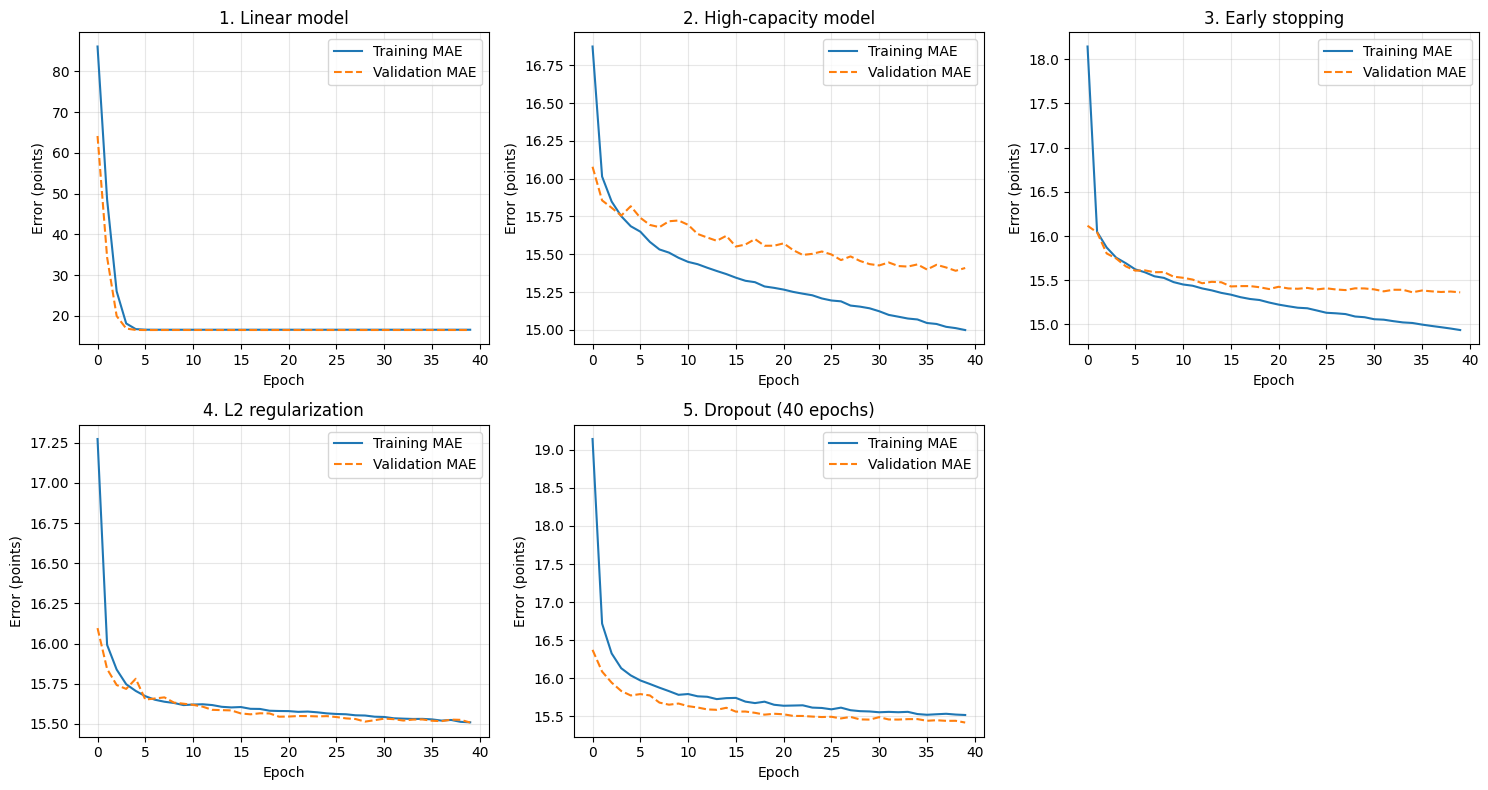

In [ ]:
def plot_history(hist, title):
    train_mae = np.array(hist.history["mae"]) * 100
    val_mae = np.array(hist.history["val_mae"]) * 100

    plt.plot(train_mae, label="Training MAE")
    plt.plot(val_mae, label="Validation MAE", linestyle="--")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Error (points)")
    plt.legend()
    plt.grid(alpha=0.3)

plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plot_history(lin_hist, "1. Linear model")

plt.subplot(2, 3, 2)
plot_history(large_hist, "2. High-capacity model")

plt.subplot(2, 3, 3)
plot_history(early_hist, "3. Early stopping")

plt.subplot(2, 3, 4)
plot_history(l2_hist, "4. L2 regularization")

plt.subplot(2, 3, 5)
plot_history(drop_hist, "5. Dropout (40 epochs)")

plt.tight_layout()
plt.show()

#### 5.1. Model 6: Dropout with Extended Training (80 Epochs)

Because dropout slows down training convergence, we test whether extending the training budget to **80 epochs** improves generalization.
Notice how the model is defined explicitly with its layers and trained for `epochs=80`.

In [ ]:
print("Training 6. Dropout Model (80 epochs)...")

# 1. Define architecture
drop80_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)
])

# 2. Compile model
drop80_model.compile(optimizer="adam", loss="mae", metrics=["mae"])

# 3. Train for 80 epochs
drop80_hist = drop80_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=256,
    verbose=0
)

print("Dropout model (80 epochs) trained successfully!")

Training 6. Dropout Model (80 epochs)...
Dropout model (80 epochs) trained successfully!


### 5.2. Analyzing the 80-Epoch Dropout Learning Curve

Let us inspect the trajectory of the 80-epoch dropout model to see if validation performance continues to improve or plateaus.

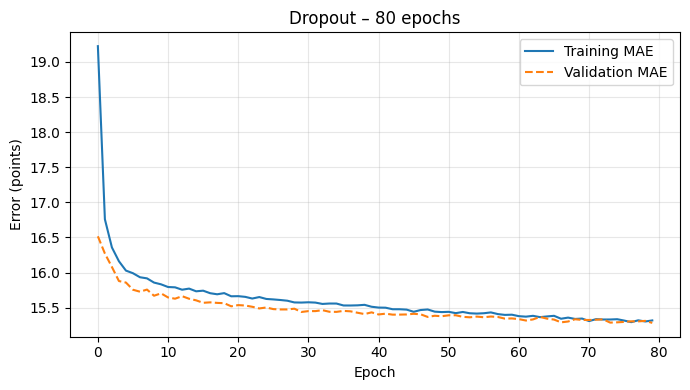

In [ ]:
plt.figure(figsize=(7, 4))
plot_history(drop80_hist, "Dropout – 80 epochs")
plt.tight_layout()
plt.show()

### 6. Model Selection on the Validation Set

We collect all 6 trained model instances into a dictionary and evaluate each on the **validation set**.
The model with the lowest validation MAE is chosen for the final evaluation.

In [ ]:
models = {
    "Linear": lin_model,
    "High-capacity": large_model,
    "Early stopping": early_model,
    "L2 regularization": l2_model,
    "Dropout (40 epochs)": drop_model,
    "Dropout (80 epochs)": drop80_model
}

print("=== VALIDATION RESULTS ===")
val_results = {}
for name, m in models.items():
    err = m.evaluate(X_val, y_val, verbose=0)[1] * 100
    val_results[name] = err
    print(f"{name:20s} -> Validation MAE: {err:.2f} points")

best_name = min(val_results, key=val_results.get)
print(f"\nBest trained model selected by validation: {best_name}")

=== VALIDATION RESULTS ===
Linear               -> Validation MAE: 16.51 points
High-capacity        -> Validation MAE: 15.41 points
Early stopping       -> Validation MAE: 15.36 points
L2 regularization    -> Validation MAE: 15.51 points
Dropout (40 epochs)  -> Validation MAE: 15.42 points
Dropout (80 epochs)  -> Validation MAE: 15.28 points

Best trained model selected by validation: Dropout (80 epochs)


### 7. One-Time Final Test Evaluation

We evaluate **only the single best model** selected via validation on the held-out test set.

In [ ]:
# FINAL EVALUATION: evaluate only the single selected model once
best_model = models[best_name]
test_mae = best_model.evaluate(X_test, y_test, verbose=0)[1] * 100
print(f"--> {best_name} FINAL TEST MAE: {test_mae:.2f} points <--")

--> Dropout (80 epochs) FINAL TEST MAE: 15.47 points <--


### 8. Summary and Key Takeaways

**Key conclusions:**
- Defining models directly exposes the full architecture: input dimensions, dense layers, activation functions, dropout probabilities, and regularizers.
- Early stopping prevents overtraining by preserving the optimal validation checkpoint.
- L2 regularization adds weight shrinkage directly to layer definitions.
- Dropout forces distributed representation across neurons.
- The test set is evaluated only once after final model selection to guarantee unbiased performance estimation.